In [107]:
import sys

sys.path.append("../../../src")

## Monthly Volatility and Return

In [108]:
from sts.data.dapi import Ticker
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [109]:
def month_stats_by_weekly_data(spy_df: pd.DataFrame, sym: str):
    spy_df["logClose"] = np.log(spy_df["Close"])
    spy_df["logReturn"] = spy_df["logClose"].diff(periods=1)
    spy_df["month"] = spy_df.index.month
    plt.rcParams.update({"font.size": 10})
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    ax1, ax2, ax3 = axes
    spy_df.boxplot(column="logReturn", by="month", ax=ax1)
    vol_df = spy_df.groupby("month")["logReturn"].std() * np.sqrt(52)
    vol_df.plot(marker="o", ax=ax2, title="vol")
    ret_df = spy_df.groupby("month")["logReturn"].mean() * 52
    ret_df.plot(marker="o", ax=ax3, title="return")
    fig.suptitle(sym)

In [110]:
symbol = "VWO"
spy = Ticker(symbol)
df = spy.history(period="30y", interval="1wk")

/home/yuqing42/miniconda3/envs/sts/lib/python3.12/site-packages/yfinance/utils.py:771: FutureWarning: The 'unit' keyword in TimedeltaIndex construction is deprecated and will be removed in a future version. Use pd.to_timedelta instead.
  df.index += _pd.TimedeltaIndex(dst_error_hours, 'h')
/home/yuqing42/miniconda3/envs/sts/lib/python3.12/site-packages/yfinance/utils.py:633: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if not _np.isnan(quotes["High"][n - 1]):
/home/yuqing42/miniconda3/envs/sts/lib/python3.12/site-packages/yfinance/utils.py:634: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  quotes.loc[idx2, "High"] =

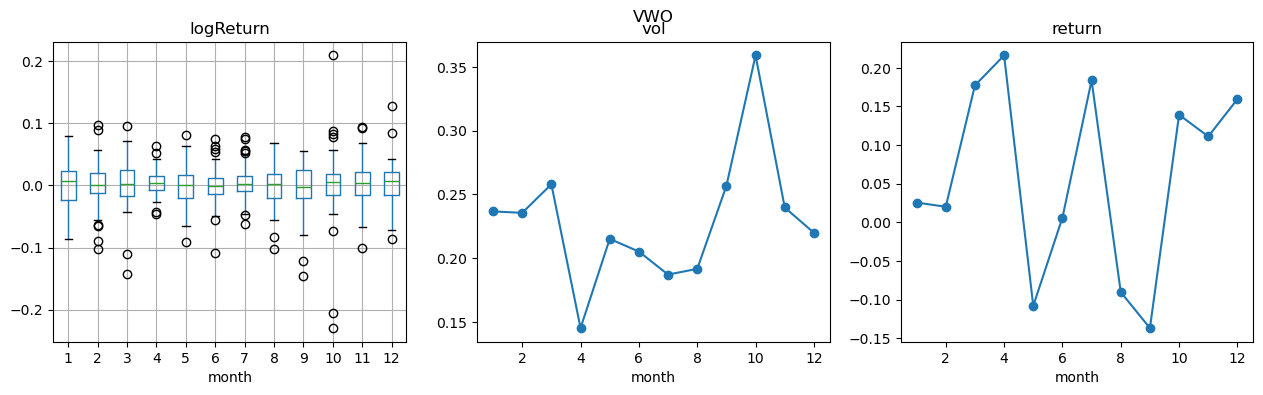

In [111]:
month_stats_by_weekly_data(df, symbol)

## October Tax Policy Impact

Due to the tax purpose, there should be a positive momentum between october performance with YTD performance

In [104]:
def get_monthly_return_corr_YTD(df: pd.DataFrame, sym: str):
    df["logClose"] = np.log(df["Close"])
    df["year"] = df.index.year
    df["month"] = df.index.month

    df["logReturn"] = df["logClose"].diff(periods=1).fillna(0)

    df["cumReturnYearly"] = df.groupby("year")["logReturn"].cumsum()

    monthly_corr_ts = (
        df.groupby("month")[["logReturn", "cumReturnYearly"]].corr().unstack().loc[:, ("logReturn", "cumReturnYearly")]
    )

    monthly_corr_ts.plot(marker="o")
    plt.title(sym + " monthly_return_corr_with_YTD_performance")

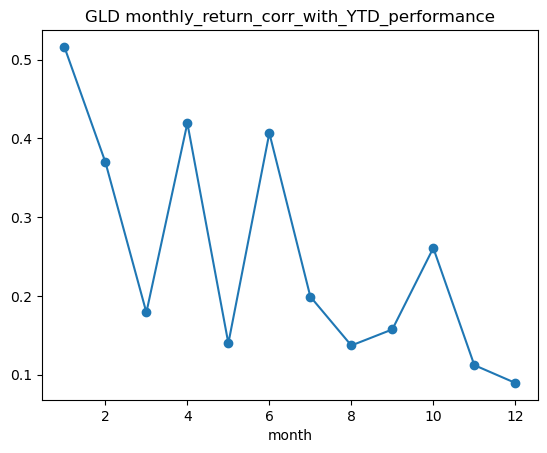

In [105]:
get_monthly_return_corr_YTD(df, symbol)

## December Tax Effects